# Imports

In [1]:
from torch_geometric.nn import HGTConv, Linear
from torch_geometric.loader import HGTLoader
from torch_geometric.data import HeteroData
import torch.nn.functional as F
# import pickle5 as pickle
import pickle
import torch.nn as nn
import pandas as pd
from utils import *
import random
import torch
import copy
import os
import sys
from tqdm import tqdm

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
node_type1 = 'drug'
node_type2 = 'disease'
rel = 'indication'

In [3]:
config = {
    "num_samples": 512,
    "batch_size": 164,
    "dropout": 0.5,
    "epochs": 300,
    "file_name": "HGTDR-5"
}

# Load data

In [4]:
primekg_file = '../data/kg.csv'
df = pd.read_csv(primekg_file, sep =",")

/tmp/ipykernel_209795/259066371.py:2: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(primekg_file, sep =",")


### Get drugs and diseases which are used in indication relation.

### Remove drug and disease nodes that do not contribute to at least one indication edge. 

In [5]:
# 确保每条边连接的是 drug 和 disease（顺序不限）
valid_rows = (
    ((df['x_type'] == 'drug') & (df['y_type'] == 'disease')) |
    ((df['x_type'] == 'disease') & (df['y_type'] == 'drug'))
)
drug_disease_pairs = df[(df['relation'] == 'indication') & valid_rows]

# 提取所有 x 和 y 的 (type, index) 对
x_mask = drug_disease_pairs['x_type'].isin([node_type1, node_type2])
y_mask = drug_disease_pairs['y_type'].isin([node_type1, node_type2])

# 合并所有有效实体
all_entities = pd.concat([
    drug_disease_pairs.loc[x_mask, ['x_type', 'x_index']].rename(columns={'x_type': 'type', 'x_index': 'index'}),
    drug_disease_pairs.loc[y_mask, ['y_type', 'y_index']].rename(columns={'y_type': 'type', 'y_index': 'index'})
])

# 分别提取 drug 和 disease
drugs = all_entities[all_entities['type'] == node_type1]['index'].unique().tolist()
diseases = all_entities[all_entities['type'] == node_type2]['index'].unique().tolist()

# 确保是 set 以加速
valid_drugs = set(drugs)
valid_diseases = set(diseases)

# 定义检查函数 (向量化操作的核心是避免 apply，但这里逻辑稍复杂，用布尔掩码最清晰)
# 检查 x 节点是否有效
check_x = (
    (~df['x_type'].isin(['drug', 'disease'])) |  # 情况1: 不是目标类型 -> 有效
    ((df['x_type'] == 'drug') & df['x_index'].isin(valid_drugs)) |      # 情况2: 是drug且在列表 -> 有效
    ((df['x_type'] == 'disease') & df['x_index'].isin(valid_diseases))  # 情况3: 是disease且在列表 -> 有效
)

# 检查 y 节点是否有效
check_y = (
    (~df['y_type'].isin(['drug', 'disease'])) |
    ((df['y_type'] == 'drug') & df['y_index'].isin(valid_drugs)) |
    ((df['y_type'] == 'disease') & df['y_index'].isin(valid_diseases))
)

# 只有 x 和 y 同时有效，才保留
df_cleaned = df[check_x & check_y].reset_index(drop=True)

# 1. 构建格式化后的列 (使用 f-string 或 vectorized string 操作)
# 注意：确保 index 列是字符串类型，防止数字和字符串拼接报错
head_nodes = df_cleaned['x_type'] + '::' + df_cleaned['x_index'].astype(str)
tail_nodes = df_cleaned['y_type'] + '::' + df_cleaned['y_index'].astype(str)

# 2. 组装新的 DataFrame
new_df = pd.DataFrame({
    0: head_nodes,
    1: df_cleaned['relation'],
    2: tail_nodes
})

# 3. 去重并转换为列表
# drop_duplicates() 会移除完全相同的行 (头-关系-尾 都相同)
df = new_df.drop_duplicates()
triplets = df.values.tolist()

# 打印预览
print(f"生成三元组数量: {len(triplets)}")
print(f"示例数据: {triplets[:3]}")

生成三元组数量: 5683172
示例数据: [['gene/protein::0', 'protein_protein', 'gene/protein::8889'], ['gene/protein::1', 'protein_protein', 'gene/protein::2798'], ['gene/protein::2', 'protein_protein', 'gene/protein::5646']]


In [6]:
entity_dictionary = {}

for src, _, dest in triplets:
    for node in [src, dest]:
        n_type, n_id = node.split('::', 1)
        
        # setdefault: 如果 key 不存在，初始化为空字典，并返回该字典
        type_dict = entity_dictionary.setdefault(n_type, {})
        
        # 如果实体不在字典中，赋予新 ID (当前长度)
        if node not in type_dict:
            type_dict[node] = len(type_dict)
            


In [7]:
from collections import defaultdict

# 使用 defaultdict 自动初始化列表，避免 if-else 判断
edge_dictionary = defaultdict(list)

for src, relation, dest in triplets:
    # 1. 解析类型 (只取 '::' 之前的部分)
    src_type = src.split('::', 1)[0]
    dest_type = dest.split('::', 1)[0]
    
    # 2. 获取整数 ID (直接从之前构建的 entity_dictionary 中查找)
    src_int_id = entity_dictionary[src_type][src]
    dest_int_id = entity_dictionary[dest_type][dest]
    
    # 3. 构建边类型键 (SrcType, Relation, DstType)
    etype = (src_type, relation, dest_type)
    
    # 4. 添加边 (defaultdict 会自动处理列表初始化)
    edge_dictionary[etype].append((src_int_id, dest_int_id))

# 如果需要转回普通字典 (可选，通常 defaultdict 也能直接用于后续处理)
edge_dictionary = dict(edge_dictionary)


节点类型组成维度 
DrugNode2Vec + ChemBERTa 128 + 767 = 895 
Non-DrugNode2Vec + PubMedBERT 128 + 768 = 896



In [8]:
# Cell 18+20: 初始化 HeteroData 并填充嵌入
import numpy as np

# 已删除 NODE2VEC_DIM 常量

CHEMBERTA_DIM  = 767
PUBMEDBERT_DIM = 768

# 加载嵌入文件
# 已删除 node2vec_df 的加载
pubmedbert_df = pd.read_pickle('../data/pubmedbert_embeddings.pkl')
smiles_df     = pd.read_pickle('../data/smiles_embeddings.pkl')

# 创建字典
# 已删除 node2vec_dict 的创建
pubmedbert_dict = dict(zip(pubmedbert_df['id'], pubmedbert_df['embedding']))
smiles_dict     = dict(zip(smiles_df['id'],     smiles_df['embedding']))

# 初始化节点特征
data = HeteroData()
for key in entity_dictionary.keys():
    num_nodes = len(entity_dictionary[key])
    # 修改维度：移除 NODE2VEC_DIM
    dim = CHEMBERTA_DIM if key == 'drug' else PUBMEDBERT_DIM
    data[key].x  = torch.zeros((num_nodes, dim))
    data[key].id = torch.arange(num_nodes)

# 添加边
for key in edge_dictionary:
    data[key].edge_index = torch.transpose(
        torch.IntTensor(edge_dictionary[key]), 0, 1
    ).long().contiguous()

# 填充嵌入
for node_type, mapping in tqdm(entity_dictionary.items(), desc='填充节点嵌入'):
    for entity_id, hgt_id in mapping.items():

        # 已删除 node2vec 嵌入的填充逻辑

        if node_type == 'drug':
            if entity_id in smiles_dict:
                data[node_type].x[hgt_id, :] = torch.tensor( # 修改索引
                    np.array(smiles_dict[entity_id], dtype=np.float32)
                )
        else:
            if entity_id in pubmedbert_dict:
                data[node_type].x[hgt_id, :] = torch.tensor( # 修改索引
                    np.array(pubmedbert_dict[entity_id], dtype=np.float32)
                )

print('节点维度:')
for k in data.node_types:
    print(f'  {k}: {data[k].x.shape}')

填充节点嵌入: 100%|██████████| 10/10 [00:03<00:00,  2.54it/s]

节点维度:
  gene/protein: torch.Size([27573, 768])
  drug: torch.Size([1801, 767])
  disease: torch.Size([1363, 768])
  effect/phenotype: torch.Size([15082, 768])
  biological_process: torch.Size([28642, 768])
  molecular_function: torch.Size([11169, 768])
  cellular_component: torch.Size([4176, 768])
  exposure: torch.Size([780, 768])
  pathway: torch.Size([2516, 768])
  anatomy: torch.Size([14035, 768])


### Load train and validation data of one fold.

In [9]:
file = open('../data/CV data/train1.pkl', 'rb')
train_data = pickle.load(file)

In [10]:
file = open('../data/CV data/val1.pkl', 'rb')
val_data = pickle.load(file)

### Creating mask.

In [11]:
# 2. 创建 Mask
# 获取边数 (逻辑与原代码完全一致)
drug_disease_num = train_data[(node_type1, rel, node_type2)]['edge_index'].shape[1]

# 随机采样 80% 的索引
mask = random.sample(range(drug_disease_num), int(drug_disease_num * 0.8))

# 初始化正向边 mask 并赋值
train_data[(node_type1, rel, node_type2)]['mask'] = torch.zeros(drug_disease_num, dtype=torch.bool)
train_data[(node_type1, rel, node_type2)]['mask'][mask] = True

# 初始化反向边 mask 并赋值 (逻辑与原代码完全一致，保持显式写出以便阅读)
train_data[(node_type2, rel, node_type1)]['mask'] = torch.zeros(drug_disease_num, dtype=torch.bool)
train_data[(node_type2, rel, node_type1)]['mask'][mask] = True

### Define model.

In [12]:
class HGT(nn.Module):
    def __init__(self, hidden_channels, out_channels, num_heads, num_layers, dropout):
        super().__init__()

        self.lin_dict = nn.ModuleDict()
        for node_type in train_data.node_types:
            self.lin_dict[node_type] = Linear(-1, hidden_channels[0])
            
        self.convs = nn.ModuleList()
        for i in range(num_layers):
            conv = HGTConv(hidden_channels[i], hidden_channels[i+1], train_data.metadata(),
                           num_heads[i])
            self.convs.append(conv)
        
        self.lin = Linear(sum(hidden_channels[1:]), out_channels)
        
        self.dropout = nn.Dropout(dropout)

    def forward(self, x_dict, edge_index_dict):
        x_dict = {
            node_type: self.dropout(self.lin_dict[node_type](x).relu_())
            for node_type, x in x_dict.items()
        }
        out = {}
        for i, conv in enumerate(self.convs):
            x_dict = conv(x_dict, edge_index_dict)

            if out=={}:
                out = copy.copy(x_dict)
            else:
                out = {
                    node_type: torch.cat((out[node_type], x_dict[node_type]), dim=1)
                    for node_type, x in x_dict.items()
                }

        return F.relu(self.lin(out[node_type1])), F.relu(self.lin(out[node_type2]))

In [13]:
class MLPPredictor(nn.Module):
    def __init__(self, channel_num, dropout):
        super().__init__()
        self.L1 = nn.Linear(channel_num * 2, channel_num)
        self.L2 = nn.Linear(channel_num, 1)
        self.bn = nn.BatchNorm1d(num_features=channel_num)
        self.dropout = nn.Dropout(0.2)

    def forward(self, drug_embeddings, disease_embeddings):
        x = torch.cat((drug_embeddings, disease_embeddings), dim=1)
        x = F.relu(self.bn(self.L1(x)))
        x = self.dropout(x)
        x = self.L2(x)
        return x

In [14]:
def compute_loss(scores, labels):
    pos_weights = torch.clone(labels)
    pos_weights[pos_weights == 1] = ((labels==0).sum() / labels.shape[0])
    pos_weights[pos_weights == 0] = ((labels==1).sum() / labels.shape[0])
    
    return F.binary_cross_entropy_with_logits(scores, labels, pos_weight=pos_weights)
#     return F.binary_cross_entropy_with_logits(scores, labels)

In [15]:
def define_model(dropout):
    GNN = HGT(hidden_channels=[64, 64, 64, 64],
              out_channels=64,
              num_heads=[8, 8, 8],
              num_layers=3,
              dropout=dropout)

    pred = MLPPredictor(64, dropout)
    model = nn.Sequential(GNN, pred)
    model.to(device)
    
    return GNN, pred, model

In [16]:
def define_loaders(config):
    kwargs = {'batch_size': config['batch_size'], 'num_workers': 8, 'persistent_workers': True}
    
    train_loader = HGTLoader(train_data, num_samples=[config['num_samples']] * 3, shuffle=True, input_nodes=(node_type1, None), **kwargs)
    val_loader = HGTLoader(val_data, num_samples=[config['num_samples']] * 3, shuffle=True, input_nodes=(node_type1, None), **kwargs)
    return train_loader, val_loader

In [17]:
def edge_exists(edges, edge):
    edges = edges.to(device)
    edge = edge.to(device)
    return (edges == edge).all(dim=0).sum() > 0

### Make batches.

In [18]:
def make_batch(batch):
  
    batch_size = batch[node_type1].batch_size
    edge_index = batch[(node_type1, rel, node_type2)]['edge_index']
    mask = batch[(node_type1, rel, node_type2)]['mask']   
    
    batch_index = (edge_index[0] < batch_size)
    edge_index = edge_index[:, batch_index]
    mask = mask[batch_index]
    edge_label_index = edge_index[:, mask]
    pos_num = edge_label_index.shape[1]
    edge_label = torch.ones(pos_num)
    
    neg_edges_source = []
    neg_edges_dest = []
    while len(neg_edges_source) < pos_num:
        source = random.randint(0, batch_size-1)
        dest = random.randint(0, batch[node_type2].x.shape[0]-1)
        neg_edge = torch.Tensor([[source], [dest]])
        if edge_exists(edge_index, neg_edge):
            continue
        else:
            neg_edges_source.append(source)
            neg_edges_dest.append(dest)
    
    neg_edges = torch.tensor([neg_edges_source, neg_edges_dest])
    edge_label_index = torch.cat((edge_label_index, neg_edges), dim=1)
    edge_label = torch.cat((edge_label, torch.zeros(neg_edges.shape[1])), dim=0)
    edge_index = edge_index[:, ~mask]

    batch[(node_type1, rel, node_type2)]['edge_index'] = edge_index
    batch[(node_type1, rel, node_type2)]['edge_label_index'] = edge_label_index
    batch[(node_type1, rel, node_type2)]['edge_label'] = edge_label
    
    batch[(node_type2, rel, node_type1)]['edge_index'] = edge_index
    temp = copy.copy(batch[(node_type2, rel, node_type1)]['edge_index'][0])
    batch[(node_type2, rel, node_type1)]['edge_index'][0] = batch[(node_type2, rel, node_type1)]['edge_index'][1]
    batch[(node_type2, rel, node_type1)]['edge_index'][1] = temp
    
    return batch

In [19]:
def make_test_batch(batch):
  
    batch_size = batch[node_type1].batch_size
    edge_index = batch[(node_type1, rel, node_type2)]['edge_index']
    edge_label_index = batch[(node_type1, rel, node_type2)]['edge_label_index']
    edge_label = batch[(node_type1, rel, node_type2)]['edge_label']
    
    source = []
    dest = []
    labels = []
    for i in range(edge_label_index.shape[1]):
        if edge_label_index[0, i] in batch[node_type1]['id'] and edge_label_index[1, i] in batch[node_type2]['id'] \
        and ((batch[node_type1]['id'] == edge_label_index[0, i]).nonzero(as_tuple=True)[0]) < batch_size:
            if edge_label[i] == 1:
                source.append((batch[node_type1]['id'] == edge_label_index[0, i]).nonzero(as_tuple=True)[0])
                dest.append((batch[node_type2]['id'] == edge_label_index[1, i]).nonzero(as_tuple=True)[0])

    edge_label_index = torch.zeros(2, len(source)).long()
    edge_label_index[0] = torch.tensor(source)
    edge_label_index[1] = torch.tensor(dest)
    pos_num = edge_label_index.shape[1]
    edge_label = torch.ones(pos_num)
    
    neg_edges_source = []
    neg_edges_dest = []
    while len(neg_edges_source) < pos_num:
        source_node = random.randint(0, batch_size-1)
        dest_node = random.randint(0, batch[node_type2].x.shape[0]-1)
        neg_edge = torch.Tensor([[source_node], [dest_node]])
        neg_edge_in_orig_graph = torch.Tensor([[batch[node_type1]['id'][source_node]], [batch[node_type2]['id'][dest_node]]])
        if edge_exists(data[(node_type1, rel, node_type2)]['edge_index'], neg_edge_in_orig_graph):
            continue
        else:
            neg_edges_source.append(source_node)
            neg_edges_dest.append(dest_node)

    neg_edges = torch.tensor([neg_edges_source, neg_edges_dest])
    edge_label_index = torch.cat((edge_label_index, neg_edges), dim=1)
    edge_label = torch.cat((edge_label, torch.zeros(neg_edges.shape[1])), dim=0)

    batch[(node_type1, rel, node_type2)]['edge_label_index'] = edge_label_index
    batch[(node_type1, rel, node_type2)]['edge_label'] = edge_label

    return batch

### Train

In [20]:
def train(GNN, pred, model, loader, optimizer):
    model.train()
    total_examples = total_loss = 0
    for i, batch in enumerate(iter(loader)):
        optimizer.zero_grad()
        batch = make_batch(batch)
        batch = batch.to(device)
        edge_label_index = batch[(node_type1, rel, node_type2)]['edge_label_index']
        edge_label = batch[(node_type1, rel, node_type2)]['edge_label']
        if edge_label.shape[0] == 0:
            continue
        
        drug_embeddings, disease_embeddings = GNN(batch.x_dict, batch.edge_index_dict)
        
        c = drug_embeddings[edge_label_index[0]]
        d = disease_embeddings[edge_label_index[1]]
        out = pred(c, d)[:, 0]
        loss = compute_loss(out, edge_label)
        loss.backward()
        optimizer.step()

        total_examples += edge_label_index.shape[1]
        # total_loss += float(loss) * edge_label_index.shape[1]
        # 方案 B (更常用): 直接使用 .item()，它会自动 detach
        total_loss += loss.item() * edge_label_index.shape[1]

    return total_loss / total_examples

### Test

In [21]:
@torch.no_grad()
def test(GNN, pred, model, loader):
    model.eval()

    total_examples = total_correct = 0
    out, labels = torch.tensor([]).to(device), torch.tensor([]).to(device)
    source, dest = torch.tensor([]).to(device), torch.tensor([]).to(device)
    for batch in iter(loader):
        batch = make_test_batch(batch)
        batch = batch.to(device)
        drug_embeddings, disease_embeddings = GNN(batch.x_dict, batch.edge_index_dict)
        
        edge_label_index = batch[(node_type1, rel, node_type2)]['edge_label_index']
        edge_label = batch[(node_type1, rel, node_type2)]['edge_label']
        
        if edge_label.shape[0] == 0:
            continue
                
        c = drug_embeddings[edge_label_index[0]]
        d = disease_embeddings[edge_label_index[1]]
        batch_out = pred(c, d)[:, 0]
        labels = torch.cat((labels, edge_label))
        out = torch.cat((out, batch_out))
        
        drugs = batch[node_type1]['id'][edge_label_index[0]]
        diseases = batch[node_type2]['id'][edge_label_index[1]]
        source = torch.cat((source, drugs))
        dest = torch.cat((dest, diseases))

    loss = compute_loss(out, labels)    
    return out, labels, source, dest, loss.cpu().numpy()

### Run

In [22]:
def run(config):
    losses, val_losses = [], []
    best_val_loss = float('inf')
    best_epoch = 0
    
    train_loader, val_loader = define_loaders(config)
    GNN, pred, model = define_model(config['dropout'])
    
    optimizer = torch.optim.AdamW(model.parameters())
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, 
                                                           T_max=config['epochs'], 
                                                           eta_min=0, 
                                                           last_epoch=-1)
    
    
    script_name = config.get("file_name")
    # 3. 拼接输出目录
    output_dir = os.path.join('..', 'out', script_name)
    # 4. 创建目录
    os.makedirs(output_dir, exist_ok=True)
    
    
    for epoch in tqdm(range(config['epochs']), desc="Training Progress"):
    # for epoch in range(config['epochs']):
        loss = train(GNN, pred, model, train_loader, optimizer)
        out, labels, source, dest, val_loss = test(GNN, pred, model, val_loader)
        
        write_to_out(f'Epoch: {epoch:02d}, Loss: {loss:.4f}, ValLoss: {val_loss:.4f} \n', output_dir)
        losses.append(loss)
        val_losses.append(val_loss)
        plot_losses(losses, val_losses, output_dir)
        scheduler.step()
        # 手动打印当前学习率
        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch}: Learning Rate = {current_lr}")
    
    
    
    # 3. 将模型也保存到该目录下
    model_save_path = os.path.join(output_dir, 'saved_model.h5')
    torch.save(model.state_dict(), model_save_path)
    
    out, labels, source, dest, val_loss = test(GNN, pred, model, val_loader)
    AUPR(out, labels, output_dir)
    AUROC(out, labels, output_dir)

In [23]:
# run(config)

In [24]:
def evaluate_only(config):
    script_name = config.get("file_name")
    output_dir = os.path.join('..', 'out', script_name)
    
    # 加载数据和模型结构
    train_loader, val_loader = define_loaders(config)
    GNN, pred, model = define_model(config['dropout'])
    
    # 加载已保存的权重
    model_save_path = os.path.join(output_dir, 'saved_model.h5')
    model.load_state_dict(torch.load(model_save_path))
    model.eval()
    
    # 推理
    out, labels, source, dest, val_loss = test(GNN, pred, model, val_loader)
    
    # 计算两个率
    AUPR(out, labels, output_dir)
    AUROC(out, labels, output_dir)

AUPR: 0.949 



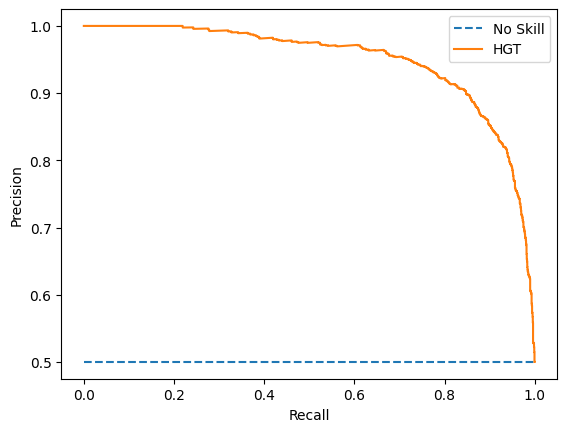

AUROC: 0.946 



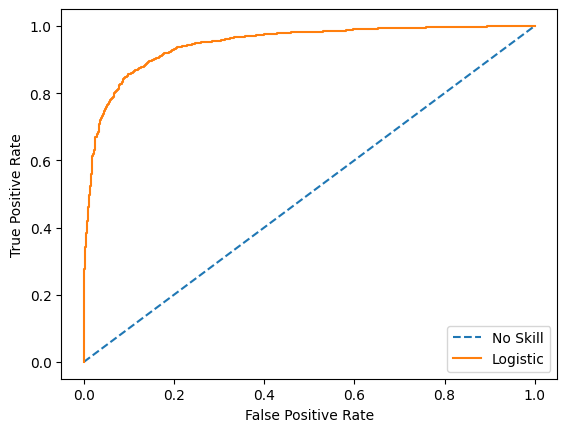

<Figure size 640x480 with 0 Axes>

In [25]:
evaluate_only(config)